In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv('/content/PLAD_Oct_2021.csv', sep=';', encoding='latin1')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1266 entries, 0 to 1265
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   idacr                1266 non-null   object
 1   leader               1266 non-null   object
 2   plad_id              1266 non-null   object
 3   archigos_id          1266 non-null   object
 4   startdate            1266 non-null   object
 5   enddate              1266 non-null   object
 6   startyear            1266 non-null   int64 
 7   endyear              1266 non-null   int64 
 8   adm0                 1266 non-null   object
 9   adm1                 1264 non-null   object
 10  adm2                 1266 non-null   object
 11  country              1266 non-null   object
 12  continent            1266 non-null   object
 13  latitude             1266 non-null   object
 14  longitude            1266 non-null   object
 15  geoname              1264 non-null   object
 16  geo_pr

In [ ]:
health = pd.read_csv('/content/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_558.csv', skiprows=4)
education = pd.read_csv('/content/API_SE.XPD.TOTL.GD.ZS_DS2_en_csv_v2_15.csv', skiprows=4)
military = pd.read_csv('/content/API_MS.MIL.XPND.GD.ZS_DS2_en_csv_v2_211.csv', skiprows=4)
def reshape_worldbank(df, value_name):
    df = df[['Country Name', 'Country Code'] + [str(y) for y in range(1989, 2021)]]
    df = df.melt(id_vars=['Country Name', 'Country Code'],
                 var_name='year',
                 value_name=value_name)
    df['year'] = df['year'].astype(int)
    return df

health_long = reshape_worldbank(health, 'health_exp')
education_long = reshape_worldbank(education, 'education_exp')
military_long = reshape_worldbank(military, 'military_exp')
# Merge all 3 spending datasets on country and year
spending = health_long.merge(education_long, on=['Country Name', 'Country Code', 'year'])
spending = spending.merge(military_long, on=['Country Name', 'Country Code', 'year'])

print(spending.shape)
print(spending.head())





(8512, 6)
                  Country Name Country Code  year  health_exp  education_exp  \
0                        Aruba          ABW  1989         NaN            NaN   
1  Africa Eastern and Southern          AFE  1989         NaN            NaN   
2                  Afghanistan          AFG  1989         NaN            NaN   
3   Africa Western and Central          AFW  1989         NaN            NaN   
4                       Angola          AGO  1989         NaN            NaN   

   military_exp  
0           NaN  
1      5.193521  
2           NaN  
3      1.111177  
4     19.432333  


In [ ]:
columns_we_need = ['leader', 'country', 'continent', 'startyear', 'endyear', 'yrborn', 'gender', 'edu_r']
df = df[columns_we_need]
df.head()
df['age_at_start'] = df['startyear'] - df['yrborn']
df.head()

,leader,country,continent,startyear,endyear,yrborn,gender,edu_r,age_at_start
0,Najibullah,Afghanistan,Asia,1986,1992,1947,M,8,39
1,Mojadidi,Afghanistan,Asia,1992,1992,1926,M,6,66
2,Burhanuddin Rabbani,Afghanistan,Asia,1992,1996,1939,M,7,53
3,Mullah Omar,Afghanistan,Asia,1996,2001,1959,M,1,37
4,Hamid Karzai,Afghanistan,Asia,2001,2014,1957,M,7,44


In [ ]:
def categorize_age(age):
    if age < 45:
        return 'Young (Under 45)'
    elif age < 60:
        return 'Middle-aged (45-59)'
    else:
        return 'Senior (60+)'

df['age_group'] = df['age_at_start'].apply(categorize_age)
df.head()
print(df['age_group'].value_counts())
print(f"\nTotal leaders: {len(df)}")

age_group
Middle-aged (45-59)    620
Senior (60+)           410
Young (Under 45)       236
Name: count, dtype: int64

Total leaders: 1266


In [ ]:
df['years_in_power'] = df['endyear'] - df['startyear']

print(df.groupby('age_group')['years_in_power'].mean().round(2))

age_group
Middle-aged (45-59)    5.00
Senior (60+)           3.53
Young (Under 45)       8.84
Name: years_in_power, dtype: float64


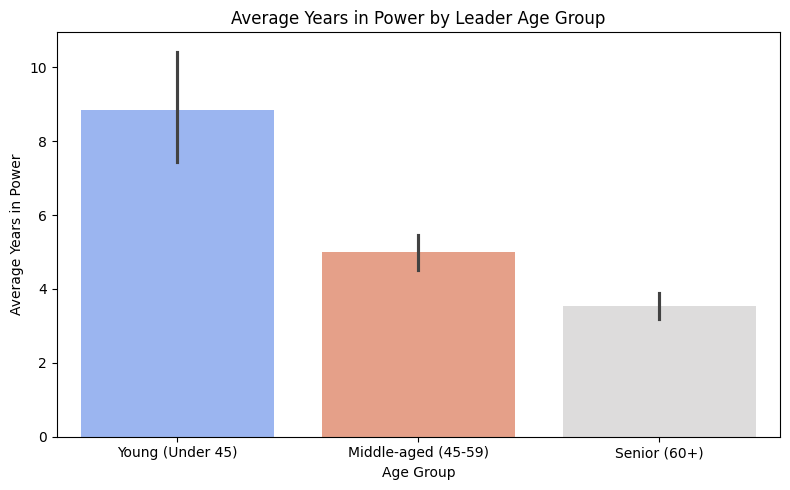

In [ ]:
order = ['Young (Under 45)', 'Middle-aged (45-59)', 'Senior (60+)']

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='age_group', y='years_in_power', order=order, hue='age_group', palette='coolwarm', legend=False)
plt.title('Average Years in Power by Leader Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Years in Power')
plt.tight_layout()
plt.show()

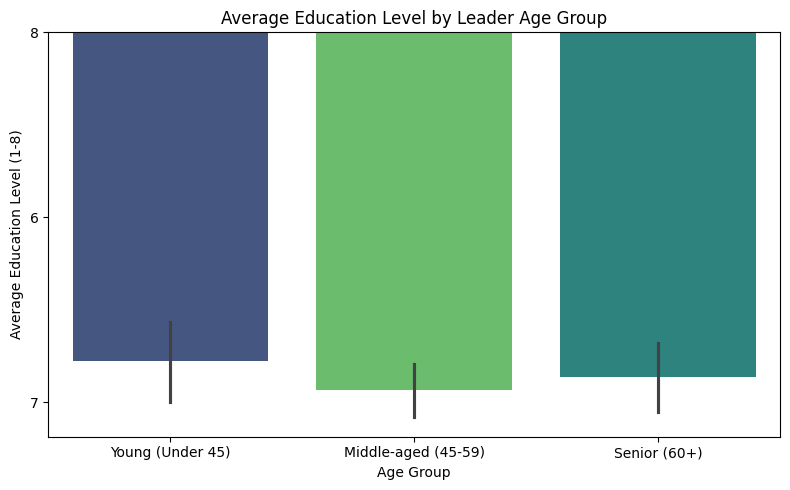

In [ ]:
order = ['Young (Under 45)', 'Middle-aged (45-59)', 'Senior (60+)']

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='age_group', y='edu_r', order=order, hue='age_group', palette='viridis', legend=False)
plt.title('Average Education Level by Leader Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Education Level (1-8)')
plt.tight_layout()
plt.show()

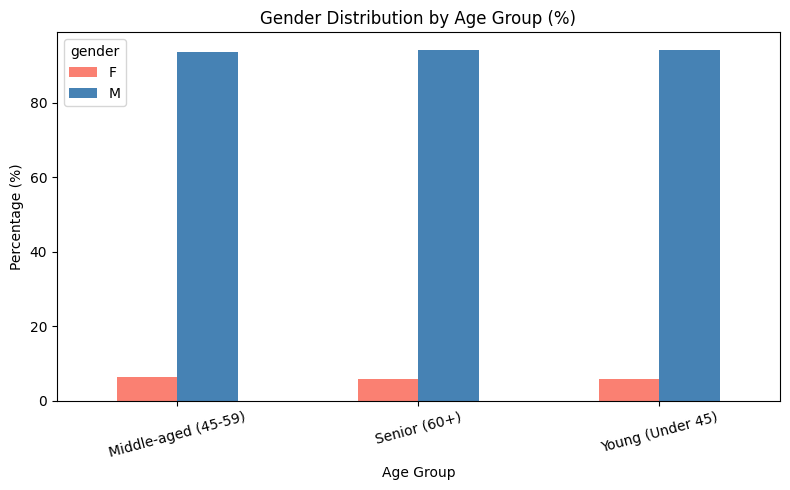

In [ ]:
gender_age = df.groupby(['age_group', 'gender']).size().unstack()
gender_age_pct = gender_age.div(gender_age.sum(axis=1), axis=0) * 100

gender_age_pct.plot(kind='bar', figsize=(8,5), color=['salmon', 'steelblue'])
plt.title('Gender Distribution by Age Group (%)')
plt.xlabel('Age Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

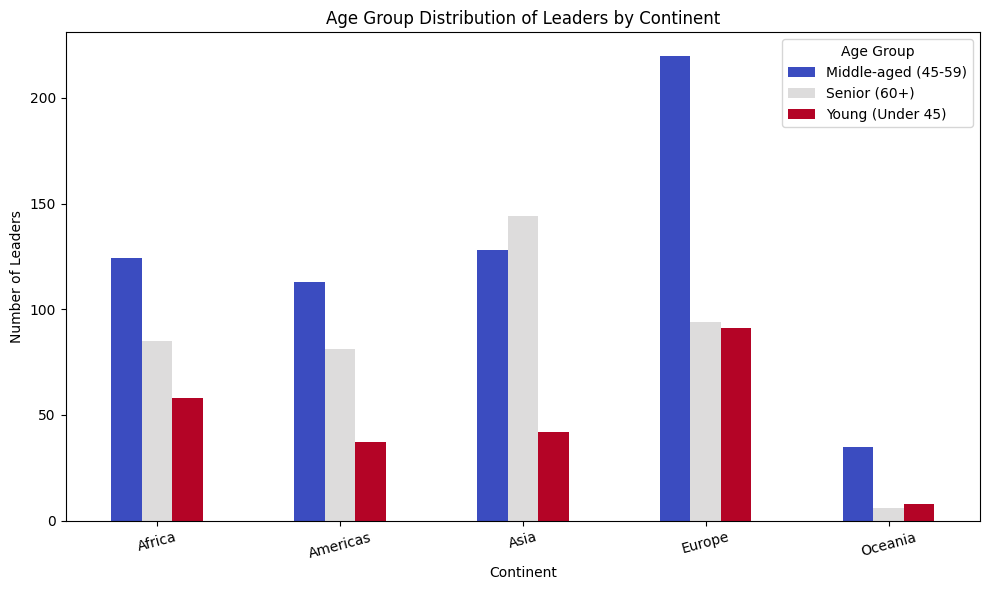

In [ ]:
continent_age = df.groupby(['continent', 'age_group']).size().unstack(fill_value=0)
continent_age.plot(kind='bar', figsize=(10, 6), colormap='coolwarm')

plt.title('Age Group Distribution of Leaders by Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Leaders')
plt.xticks(rotation=15)
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()

In [ ]:
young = df[df['age_group'] == 'Young (Under 45)']['years_in_power']
senior = df[df['age_group'] == 'Senior (60+)']['years_in_power']

t_stat, p_value = stats.ttest_ind(young, senior)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically SIGNIFICANT difference!")
else:
    print("Result: No statistically significant difference")

T-statistic: 8.5589
P-value: 0.0000
Result: Statistically SIGNIFICANT difference!


In [ ]:
# Create a row for each year a leader was in power
rows = []
for _, leader in df.iterrows():
    for year in range(leader['startyear'], leader['endyear'] + 1):
        row = leader.to_dict()
        row['year'] = year
        rows.append(row)

df_expanded = pd.DataFrame(rows)
print(df_expanded.shape)
print(df_expanded.head())

(7900, 12)
       leader      country continent  startyear  endyear  yrborn gender edu_r  \
0  Najibullah  Afghanistan      Asia       1986     1992    1947      M     8   
1  Najibullah  Afghanistan      Asia       1986     1992    1947      M     8   
2  Najibullah  Afghanistan      Asia       1986     1992    1947      M     8   
3  Najibullah  Afghanistan      Asia       1986     1992    1947      M     8   
4  Najibullah  Afghanistan      Asia       1986     1992    1947      M     8   

   age_at_start         age_group  years_in_power  year  
0            39  Young (Under 45)               6  1986  
1            39  Young (Under 45)               6  1987  
2            39  Young (Under 45)               6  1988  
3            39  Young (Under 45)               6  1989  
4            39  Young (Under 45)               6  1990  


In [ ]:
df_merged = df_expanded.merge(
    spending,
    left_on=['country', 'year'],
    right_on=['Country Name', 'year'],
    how='left'
)

print(df_merged.shape)
print(df_merged[['leader', 'country', 'year', 'age_group', 'military_exp', 'education_exp', 'health_exp']].head(10))

(7900, 17)
                leader      country  year            age_group  military_exp  \
0           Najibullah  Afghanistan  1986     Young (Under 45)           NaN   
1           Najibullah  Afghanistan  1987     Young (Under 45)           NaN   
2           Najibullah  Afghanistan  1988     Young (Under 45)           NaN   
3           Najibullah  Afghanistan  1989     Young (Under 45)           NaN   
4           Najibullah  Afghanistan  1990     Young (Under 45)           NaN   
5           Najibullah  Afghanistan  1991     Young (Under 45)           NaN   
6           Najibullah  Afghanistan  1992     Young (Under 45)           NaN   
7             Mojadidi  Afghanistan  1992         Senior (60+)           NaN   
8  Burhanuddin Rabbani  Afghanistan  1992  Middle-aged (45-59)           NaN   
9  Burhanuddin Rabbani  Afghanistan  1993  Middle-aged (45-59)           NaN   

   education_exp  health_exp  
0            NaN         NaN  
1            NaN         NaN  
2            Na

In [ ]:
print(df_merged[['military_exp', 'education_exp', 'health_exp']].notna().sum())

military_exp     4570
education_exp    3325
health_exp       3492
dtype: int64


In [ ]:
spending_by_age = df_merged.groupby('age_group')[['military_exp', 'education_exp', 'health_exp']].mean().round(2)
print(spending_by_age)

                     military_exp  education_exp  health_exp
age_group                                                   
Middle-aged (45-59)          2.02           4.43        5.90
Senior (60+)                 2.51           4.31        6.16
Young (Under 45)             2.50           4.33        6.06


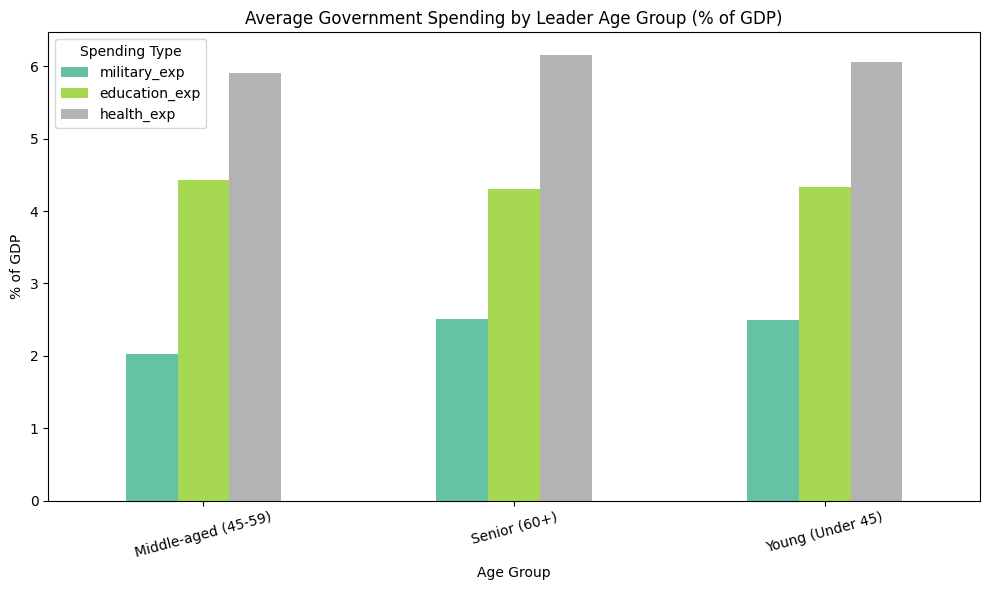

In [ ]:
spending_by_age.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title('Average Government Spending by Leader Age Group (% of GDP)')
plt.xlabel('Age Group')
plt.ylabel('% of GDP')
plt.xticks(rotation=15)
plt.legend(title='Spending Type')
plt.tight_layout()
plt.show()

In [ ]:
gender_spending = df_merged.groupby('gender')[['military_exp', 'education_exp', 'health_exp']].mean().round(2)
print(gender_spending)

        military_exp  education_exp  health_exp
gender                                         
F               1.72           4.51        6.83
M               2.31           4.36        5.95


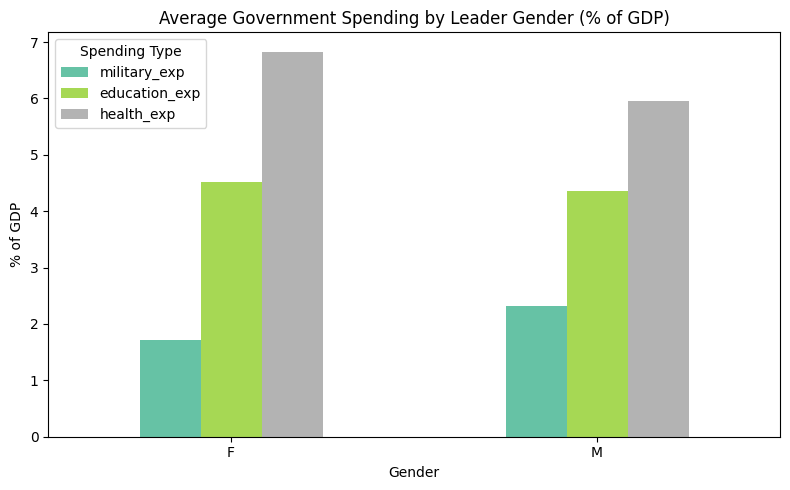

In [ ]:
gender_spending.plot(kind='bar', figsize=(8, 5), colormap='Set2')
plt.title('Average Government Spending by Leader Gender (% of GDP)')
plt.xlabel('Gender')
plt.ylabel('% of GDP')
plt.xticks(rotation=0)
plt.legend(title='Spending Type')
plt.tight_layout()
plt.show()